# Early COVID-19 Data Analysis

### A historical analytical snapshot from the first months of the pandemic

**NYU Stern Data Bootcamp · Spring 2020**  
**Analysis period:** primarily through May 12–13, 2020

---

This notebook is a restored and polished version of a three-person final project originally developed during the first wave of COVID-19 in New York City.

The restoration preserves the original analytical questions, historical data period, and collaborative work while improving presentation, reproducibility, code clarity, and interpretation.

## Project questions

Using Python and publicly available COVID-19 and financial data, the project explored four main questions:

1. Which countries were reporting the highest COVID-19 case counts?
2. How was the pandemic developing across the United States and New York City?
3. Which state-level factors were associated with differences in COVID-19 testing?
4. How did selected financial markets and companies behave during the early months of the pandemic?

Because the analysis was conducted while the pandemic was still unfolding, the results should be interpreted as a historical snapshot rather than a retrospective assessment using later knowledge.

## Analysis roadmap

**01 · Global COVID-19 snapshot**  
Global totals, country rankings, interactive visualizations, geographic patterns, population-adjusted comparisons, and case progression.

**02 · United States**  
State-level case patterns, geographic visualization, and daily case development.

**03 · New York City**  
Daily cases, hospitalizations, deaths, and demographic patterns by age and sex.

**04 · State-level testing regression**  
Exploratory relationships between COVID-19 testing and selected state characteristics.

**05 · Financial-market analysis**  
Major US indices, selected companies, and gold prices during the early pandemic period.

**06 · Limitations & conclusion**  
Historical context, methodological limitations, and key observations.

<br/>

# Part I: Visualizations

## A. Analysis of global COVID-19 data collected by Johns Hopkins University (JHU).

<font size='3'> The data from the COVID-19 Data Repository collected by the Center for Systems Science and Engineering (CSSE) at JHU has been made public and is being used extensively by the data analyzers around the world. Here we use this data to create interactive visualizations that show a picture of the COVID-19 situation globally by using matplotlib, plotly and folium packages.

This section consits of three global datasets namely:

a. **time_series_covid19_deaths_global.csv** - This dataset displays the daily(dates as variables) deaths globally by Country/Region and Province/State (time series).Latitude and Longitude of the region are also included as variables.

b. **time_series_covid19_confirmed_global.csv** - This dataset displays the daily cumulative confirmed cases in Province/State in a Country/Region. Latitude and Longitude of the region are also included as variables.
    
c. **time_series_covid19_recovered_global.csv** - This dataset displays the daily cumulative revovered cases in Province/State in a Country/Region. Latitude and Longitude of the region are also included as variables.

d. **cases_country.csv** - Data from https://github.com/CSSEGISandData/COVID-19/tree/web-data/data. This data set consists of the following key variables:
*  __Country_Region__ 
*  **Last_Update** : Last date when the data was updated
*  **Lat** : Latitude 
* **Long**: Longitude
* **Confirmed** : Confirmed cases include presumptive positive cases and probable cases, , in accordance with CDC guidelines as of April 14.
* **Deaths** : Death totals in the US include confirmed and probable, in accordance with CDC guidelines as of April 14.
* **Recovered** : Recovered cases outside China are estimates based on local media reports, and state and local reporting when available, and therefore may be substantially lower than the true number. US state-level recovered cases are from COVID Tracking Project.
* **Active** : [Confirmed - (Deaths + Recovered)]
* **Incidence_Rate** : Rate of incidence considering cases from State and Country.
* **Mortality_Rate** : Rate of death

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import folium
from folium.plugins import HeatMap

from IPython.display import display, HTML

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Locate the repository whether the kernel starts in the repo root
# or inside the notebooks/ directory.
cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate the project data directory.")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
JHU_DATA_DIR = RAW_DATA_DIR / "jhu"

# Frozen Johns Hopkins historical snapshots
CoV_deaths = pd.read_csv(
    JHU_DATA_DIR / "time_series_covid19_deaths_global.csv"
)

CoV_confirmed = pd.read_csv(
    JHU_DATA_DIR / "time_series_covid19_confirmed_global.csv"
)

CoV_recovered = pd.read_csv(
    JHU_DATA_DIR / "time_series_covid19_recovered_global.csv"
)

CoV_country = pd.read_csv(
    JHU_DATA_DIR / "cases_country.csv"
)

In [3]:
print("Project root:", PROJECT_ROOT)
print()
print("Global deaths:", CoV_deaths.shape)
print("Global confirmed:", CoV_confirmed.shape)
print("Global recovered:", CoV_recovered.shape)
print("Country snapshot:", CoV_country.shape)

print()
print("Time-series through:", CoV_confirmed.columns[-1])
print("Country snapshot updated:", CoV_country["Last_Update"].iloc[0])

Project root: /Users/meghasharma/Documents/Github/Databootcamp_project_2020_covid19_analysis/nyu-covid19-data-analysis

Global deaths: (266, 117)
Global confirmed: (266, 117)
Global recovered: (253, 117)
Country snapshot: (188, 14)

Time-series through: 5/13/20
Country snapshot updated: 2020-05-13 23:32:26


### Data preparation

Column names are standardized for consistency while preserving the structure
and historical values of the original datasets.

Missing values are retained where they represent unavailable historical
information rather than being automatically imputed.

In [6]:
# Standardize column names
for df in [CoV_deaths, CoV_confirmed, CoV_recovered, CoV_country]:
    df.columns = df.columns.str.lower()

# Use consistent geographic field names
rename_global = {
    "province/state": "state",
    "country/region": "country",
}

CoV_deaths = CoV_deaths.rename(columns=rename_global)
CoV_confirmed = CoV_confirmed.rename(columns=rename_global)
CoV_recovered = CoV_recovered.rename(columns=rename_global)

CoV_country = CoV_country.rename(
    columns={
        "country_region": "country",
        "long_": "long",
    }
)

display(CoV_country.head())

,country,last_update,lat,long,confirmed,deaths,recovered,active,incident_rate,people_tested,people_hospitalized,mortality_rate,uid,iso3
0,Australia,2020-05-13 23:32:26,-25.0000,133.0000,6979,98,6271,610,27.411949,NaN,NaN,1.404213,36,AUS
1,Austria,2020-05-13 23:32:26,47.5162,14.5501,15997,624,14304,1069,177.618138,NaN,NaN,3.900731,40,AUT
2,Canada,2020-05-13 23:32:26,60.0010,-95.0010,73563,5425,35177,32961,194.324755,NaN,NaN,7.374631,124,CAN
3,China,2020-05-13 23:32:26,30.5928,114.3055,84021,4637,79242,142,5.981520,NaN,NaN,5.518858,156,CHN
4,Denmark,2020-05-13 23:32:26,56.0000,10.0000,10865,533,8861,1471,187.579752,NaN,NaN,4.905660,208,DNK


In [7]:
assert CoV_confirmed.columns[-1] == "5/13/20"
assert CoV_country["last_update"].iloc[0] == "2020-05-13 23:32:26"

print("Historical JHU inputs loaded and standardized successfully.")

Historical JHU inputs loaded and standardized successfully.


### Global overview

Reported global totals provide a high-level view of the pandemic at the end of
the historical analysis window. The figures below reflect the JHU country-level
snapshot from May 13, 2020.

In [8]:
global_totals = {
    "Confirmed": int(CoV_country["confirmed"].sum()),
    "Deaths": int(CoV_country["deaths"].sum()),
    "Recovered": int(CoV_country["recovered"].sum()),
    "Active": int(CoV_country["active"].sum()),
}

global_totals

{'Confirmed': 4342565,
 'Deaths': 296690,
 'Recovered': 1546811,
 'Active': 2504227}

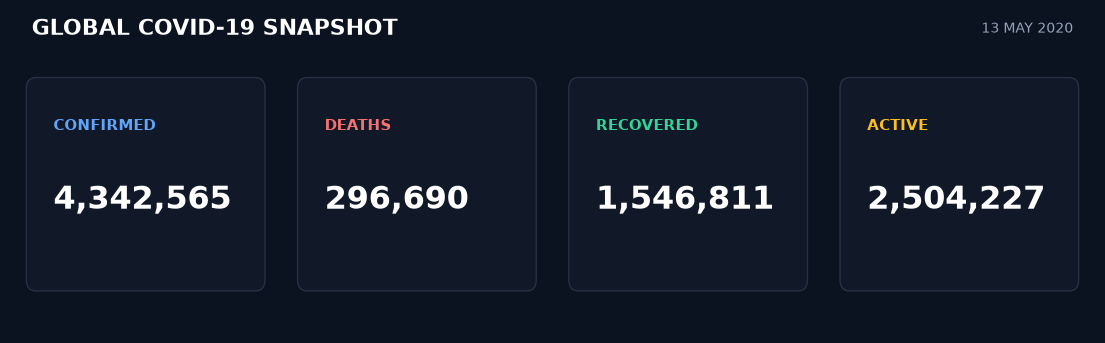

In [9]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 4.2))
ax.set_xlim(0, 4)
ax.set_ylim(0, 1)
ax.axis("off")

fig.patch.set_facecolor("#0B1220")
ax.set_facecolor("#0B1220")

labels = ["CONFIRMED", "DEATHS", "RECOVERED", "ACTIVE"]
values = [
    global_totals["Confirmed"],
    global_totals["Deaths"],
    global_totals["Recovered"],
    global_totals["Active"],
]

accent_colors = ["#60A5FA", "#F87171", "#34D399", "#FBBF24"]

for i, (label, value, accent) in enumerate(zip(labels, values, accent_colors)):
    x = i + 0.08

    card = FancyBboxPatch(
        (x, 0.15),
        0.84,
        0.62,
        boxstyle="round,pad=0.02,rounding_size=0.035",
        linewidth=1,
        edgecolor="#263244",
        facecolor="#111827",
    )
    ax.add_patch(card)

    ax.text(
        x + 0.08, 0.64, label,
        fontsize=11,
        fontweight="bold",
        color=accent,
        ha="left",
        va="center",
    )

    ax.text(
        x + 0.08, 0.41, f"{value:,.0f}",
        fontsize=23,
        fontweight="bold",
        color="white",
        ha="left",
        va="center",
    )

ax.text(
    0.08, 0.94,
    "GLOBAL COVID-19 SNAPSHOT",
    fontsize=16,
    fontweight="bold",
    color="white",
    ha="left",
    va="center",
)

ax.text(
    3.92, 0.94,
    "13 MAY 2020",
    fontsize=10,
    color="#94A3B8",
    ha="right",
    va="center",
)

plt.show()

The May 13 snapshot records reported cumulative cases rather than estimates of
the pandemic's eventual scale. Differences in testing capacity, reporting
practices, and data availability across countries should be considered when
comparing these totals.

### Country-level patterns

Country rankings provide a clearer view of how reported case burden differed
across the most affected countries by May 13, 2020.

The original project explored these patterns through interactive tables,
bubble charts, and bar charts. The restored version consolidates those views
into a single interactive comparison of confirmed cases, deaths, and
recoveries.

In [10]:
top_confirmed = (
    CoV_country
    .nlargest(10, "confirmed")
    .sort_values("confirmed")
)

top_deaths = (
    CoV_country
    .nlargest(10, "deaths")
    .sort_values("deaths")
)

top_recovered = (
    CoV_country
    .nlargest(10, "recovered")
    .sort_values("recovered")
)

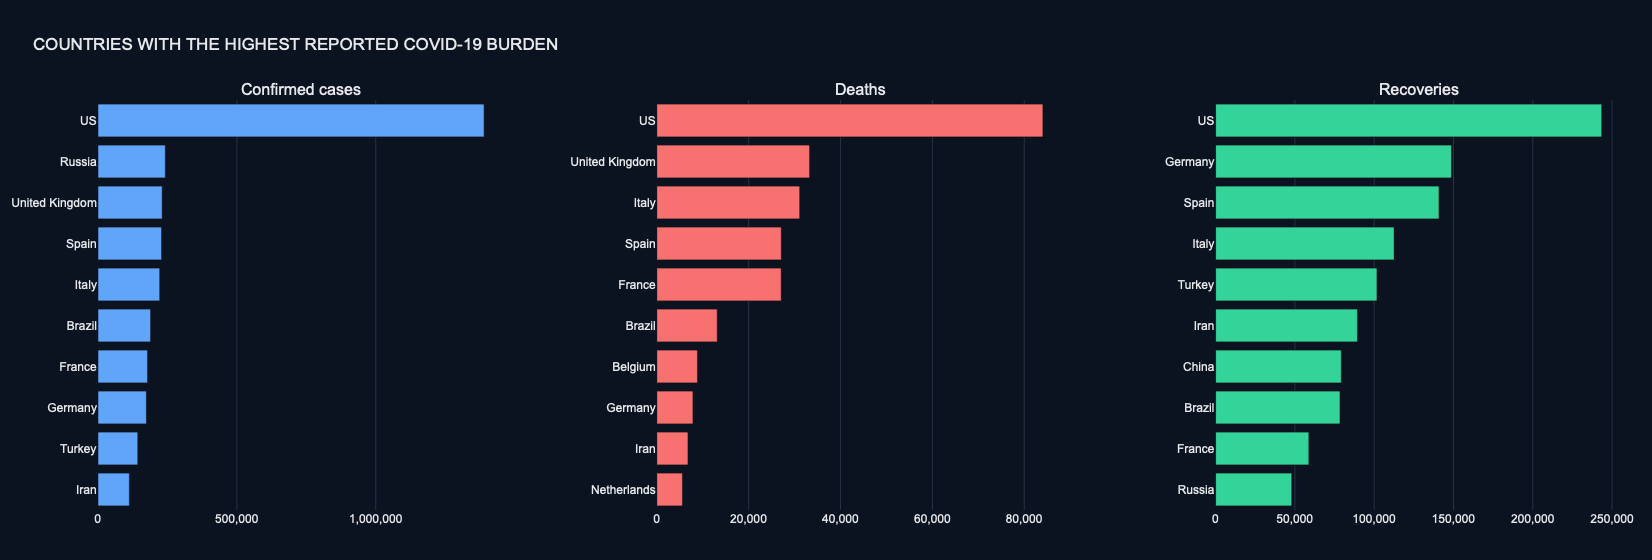

In [11]:
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=(
        "Confirmed cases",
        "Deaths",
        "Recoveries",
    ),
    horizontal_spacing=0.10,
)

fig.add_trace(
    go.Bar(
        x=top_confirmed["confirmed"],
        y=top_confirmed["country"],
        orientation="h",
        marker_color="#60A5FA",
        customdata=top_confirmed[["deaths", "recovered", "active"]],
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Confirmed: %{x:,.0f}<br>"
            "Deaths: %{customdata[0]:,.0f}<br>"
            "Recovered: %{customdata[1]:,.0f}<br>"
            "Active: %{customdata[2]:,.0f}"
            "<extra></extra>"
        ),
        showlegend=False,
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Bar(
        x=top_deaths["deaths"],
        y=top_deaths["country"],
        orientation="h",
        marker_color="#F87171",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Deaths: %{x:,.0f}"
            "<extra></extra>"
        ),
        showlegend=False,
    ),
    row=1,
    col=2,
)

fig.add_trace(
    go.Bar(
        x=top_recovered["recovered"],
        y=top_recovered["country"],
        orientation="h",
        marker_color="#34D399",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Recovered: %{x:,.0f}"
            "<extra></extra>"
        ),
        showlegend=False,
    ),
    row=1,
    col=3,
)

fig.update_layout(
    title={
        "text": "COUNTRIES WITH THE HIGHEST REPORTED COVID-19 BURDEN",
        "x": 0.02,
        "xanchor": "left",
    },
    template="plotly_dark",
    paper_bgcolor="#0B1220",
    plot_bgcolor="#0B1220",
    height=560,
    width=1200,
    margin=dict(l=60, r=30, t=100, b=50),
    font=dict(
        family="Arial",
        color="#E5E7EB",
    ),
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="#263244",
    zeroline=False,
    tickformat=",",
)

fig.update_yaxes(
    showgrid=False,
)

fig.show()

The rankings show that the countries with the highest confirmed case counts
were not necessarily ranked identically by deaths or recoveries. These
differences reflect both the progression of outbreaks and substantial
variation in testing, reporting, and recovery definitions across countries.

<font size='3'>In this graph we mark data points from confirmed cases on a geographical map. To achieve this, we used the <i>folium</i> library and the data points in latitude and longitude variables for each country/region.

### Geographic distribution

Reported cases were geographically widespread by mid-May 2020, but the
concentration of reported cases varied substantially across countries.

The map below uses the country-level latitude and longitude coordinates from
the historical JHU snapshot. Marker size reflects reported confirmed cases.

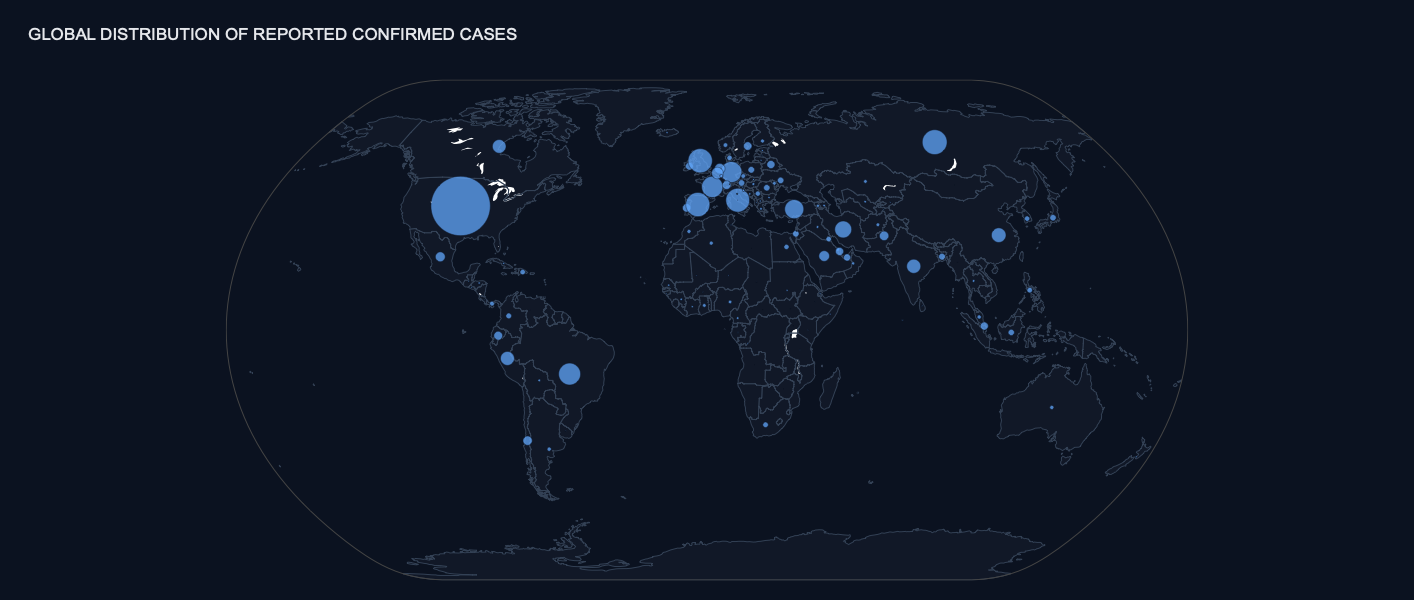

In [12]:
map_data = (
    CoV_country[
        ["country", "lat", "long", "confirmed", "deaths", "recovered"]
    ]
    .dropna(subset=["lat", "long", "confirmed"])
    .copy()
)

fig = px.scatter_geo(
    map_data,
    lat="lat",
    lon="long",
    size="confirmed",
    hover_name="country",
    hover_data={
        "confirmed": ":,.0f",
        "deaths": ":,.0f",
        "recovered": ":,.0f",
        "lat": False,
        "long": False,
    },
    size_max=42,
    projection="natural earth",
)

fig.update_traces(
    marker=dict(
        color="#60A5FA",
        line=dict(width=0.5, color="#0B1220"),
        opacity=0.75,
    )
)

fig.update_geos(
    showcoastlines=False,
    showcountries=True,
    countrycolor="#334155",
    showland=True,
    landcolor="#111827",
    showocean=True,
    oceancolor="#0B1220",
    bgcolor="#0B1220",
)

fig.update_layout(
    title={
        "text": "GLOBAL DISTRIBUTION OF REPORTED CONFIRMED CASES",
        "x": 0.02,
        "xanchor": "left",
    },
    paper_bgcolor="#0B1220",
    font=dict(
        family="Arial",
        color="#E5E7EB",
    ),
    height=600,
    margin=dict(l=20, r=20, t=80, b=20),
)

fig.show()

The map emphasizes the uneven geographic concentration of reported cases rather
than implying that marker size represents true infection prevalence. Cross-country
differences in testing coverage and reporting practices remain important
limitations of the comparison.

### Population-adjusted comparison

Raw case counts can obscure differences in country size. To add context, the
original project compared reported confirmed cases with 2018 population data
from the World Bank.

The restored analysis retains the same eight-country comparison while matching
COVID-19 and population records explicitly by country name rather than by
dataframe row position.

The resulting percentages represent **reported confirmed cases as a share of
2018 population**. They should not be interpreted as estimates of true infection
prevalence.

In [13]:
population = pd.read_csv(
    RAW_DATA_DIR / "country_population_2018.csv"
)

population_2018 = (
    population[["Country Name", "2018"]]
    .rename(
        columns={
            "Country Name": "population_country",
            "2018": "population_2018",
        }
    )
)

selected_countries = [
    "US",
    "Italy",
    "China",
    "Sweden",
    "New Zealand",
    "Korea, South",
    "Argentina",
    "India",
]

country_name_map = {
    "US": "United States",
    "Korea, South": "Korea, Rep.",
}

population_comparison = (
    CoV_country.loc[
        CoV_country["country"].isin(selected_countries),
        ["country", "confirmed", "deaths", "recovered", "active"],
    ]
    .copy()
)

population_comparison["population_country"] = (
    population_comparison["country"]
    .replace(country_name_map)
)

population_comparison = population_comparison.merge(
    population_2018,
    on="population_country",
    how="left",
    validate="one_to_one",
)

population_comparison["confirmed_pct_population"] = (
    population_comparison["confirmed"]
    / population_comparison["population_2018"]
    * 100
)

population_comparison[
    [
        "country",
        "confirmed",
        "population_2018",
        "confirmed_pct_population",
    ]
].sort_values(
    "confirmed_pct_population",
    ascending=False,
)

,country,confirmed,population_2018,confirmed_pct_population
3,US,1389935,3.266875e+08,0.425463
1,Italy,222104,6.042176e+07,0.367589
2,Sweden,27909,1.017521e+07,0.274284
7,New Zealand,1497,4.841000e+06,0.030923
6,"Korea, South",10962,5.160663e+07,0.021241
4,Argentina,6879,4.449450e+07,0.015460
0,China,84021,1.392730e+09,0.006033
5,India,78055,1.352617e+09,0.005771


In [14]:
assert population_comparison["population_2018"].notna().all()
assert len(population_comparison) == 8

print("All eight selected countries matched successfully.")

All eight selected countries matched successfully.


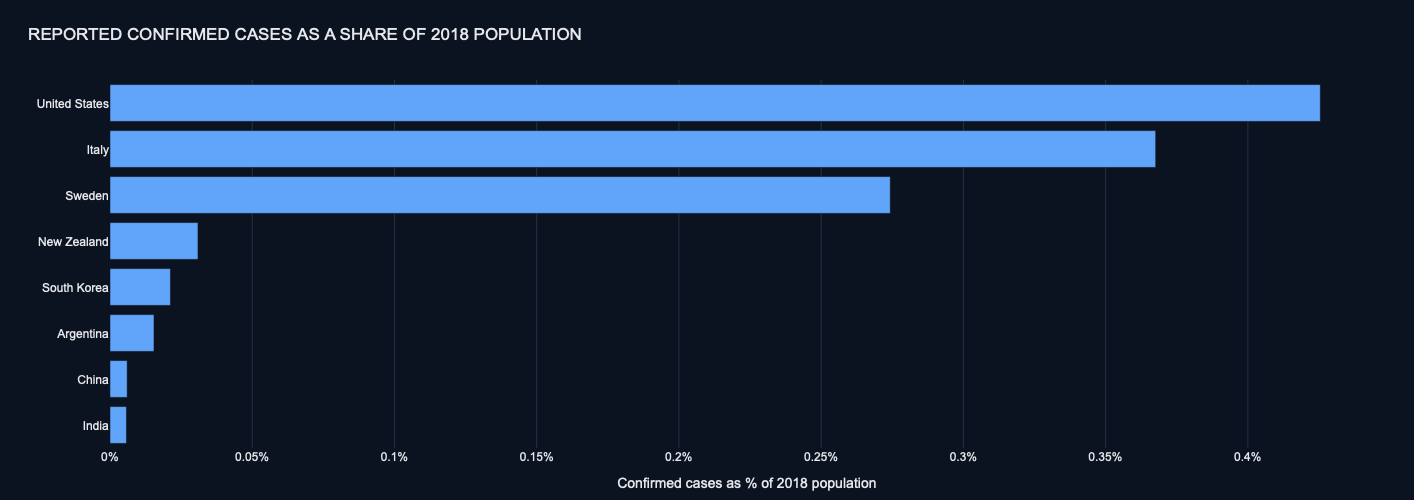

In [19]:
population_plot = (
    population_comparison
    .sort_values("confirmed_pct_population")
    .copy()
)

# Presentation-friendly labels only;
# underlying historical country names remain unchanged.
population_plot["display_country"] = (
    population_plot["country"]
    .replace(
        {
            "US": "United States",
            "Korea, South": "South Korea",
        }
    )
)

fig = go.Figure(
    go.Bar(
        x=population_plot["confirmed_pct_population"],
        y=population_plot["display_country"],
        orientation="h",
        marker_color="#60A5FA",
        customdata=population_plot[
            ["confirmed", "population_2018"]
        ],
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Confirmed cases: %{customdata[0]:,.0f}<br>"
            "2018 population: %{customdata[1]:,.0f}<br>"
            "Reported cases / population: %{x:.3f}%"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    title={
        "text": "REPORTED CONFIRMED CASES AS A SHARE OF 2018 POPULATION",
        "x": 0.02,
        "xanchor": "left",
    },
    template="plotly_dark",
    paper_bgcolor="#0B1220",
    plot_bgcolor="#0B1220",
    height=500,
    margin=dict(l=80, r=30, t=80, b=50),
    font=dict(
        family="Arial",
        color="#E5E7EB",
    ),
    xaxis_title="Confirmed cases as % of 2018 population",
    yaxis_title="",
)

fig.update_xaxes(
    gridcolor="#263244",
    zeroline=False,
    ticksuffix="%",
)

fig.show()

Adjusting for population changes the comparison substantially: countries with
the largest absolute case totals are not necessarily those with the largest
reported case burden relative to population size.

This comparison remains dependent on differences in testing and reporting
between countries and uses 2018 population figures, consistent with the
historical project.

### COVID-19 progression over time

The original project included an animated bar-chart race showing how the
countries with the highest reported confirmed case counts changed during the
early months of the pandemic.

The visualization was developed by a teammate after it was proposed as an
additional project feature. The implementation was adapted from bar-chart-race
examples by **Pratap Vardhan** and **John Burn-Murdoch**, whose work was also
credited in the original 2020 notebook.

For computational efficiency and consistency with the historical project, the
animation begins on February 25, 2020.

In [21]:
import matplotlib.animation as animation
import matplotlib.ticker as ticker

# Historical date columns in the frozen JHU dataset
non_date_columns = {"state", "country", "lat", "long"}

date_columns = [
    col
    for col in CoV_confirmed.columns
    if col not in non_date_columns
]

parsed_dates = pd.to_datetime(
    date_columns,
    format="%m/%d/%y"
)

animation_dates = [
    col
    for col, date in zip(date_columns, parsed_dates)
    if date >= pd.Timestamp("2020-02-25")
]

# Work from a contiguous copy before aggregating province/state rows
confirmed_base = (
    CoV_confirmed[
        ["country"] + date_columns
    ]
    .copy()
)

confirmed_country = (
    confirmed_base
    .groupby("country", as_index=False)[date_columns]
    .sum()
)

# Countries with the highest totals at the end of the analysis window
animation_countries = (
    confirmed_country
    .nlargest(14, date_columns[-1])["country"]
    .tolist()
)

confirmed_animation = (
    confirmed_country[
        confirmed_country["country"].isin(animation_countries)
    ]
    .melt(
        id_vars="country",
        value_vars=animation_dates,
        var_name="date",
        value_name="confirmed",
    )
)

confirmed_animation["date"] = pd.to_datetime(
    confirmed_animation["date"],
    format="%m/%d/%y"
)

frame_dates = (
    confirmed_animation["date"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Animation period:")
print(frame_dates[0], "to", frame_dates[-1])
print("Frames:", len(frame_dates))

Animation period:
2020-02-25 00:00:00 to 2020-05-13 00:00:00
Frames: 79


In [25]:
animation_colors = {
    country: color
    for country, color in zip(
        animation_countries,
        plt.cm.tab20.colors,
    )
}

display_country_names = {
    "US": "United States",
    "Korea, South": "South Korea",
}

fig, ax = plt.subplots(figsize=(12, 7))

def draw_barchart(date):
    frame = (
        confirmed_animation[
            confirmed_animation["date"].eq(date)
        ]
        .sort_values("confirmed", ascending=True)
        .tail(12)
        .copy()
    )

    frame["display_country"] = (
        frame["country"]
        .replace(display_country_names)
    )

    ax.clear()

    fig.patch.set_facecolor("#0B1220")
    ax.set_facecolor("#0B1220")

    ax.barh(
        frame["display_country"],
        frame["confirmed"],
        color=[
            animation_colors[country]
            for country in frame["country"]
        ],
    )

    max_value = max(frame["confirmed"].max(), 1)
    offset = max_value / 80

    for i, value in enumerate(frame["confirmed"]):
        ax.text(
            value + offset,
            i,
            f"{value:,.0f}",
            va="center",
            color="#E5E7EB",
            fontsize=10,
        )

    ax.text(
        0.98,
        0.08,
        pd.Timestamp(date).strftime("%d %b %Y").upper(),
        transform=ax.transAxes,
        ha="right",
        color="#94A3B8",
        fontsize=24,
        fontweight="bold",
    )

    ax.set_title(
        "COUNTRIES WITH THE HIGHEST REPORTED CONFIRMED CASES",
        loc="left",
        color="white",
        fontsize=15,
        fontweight="bold",
        pad=18,
    )

    ax.xaxis.set_major_formatter(
        ticker.StrMethodFormatter("{x:,.0f}")
    )

    ax.tick_params(axis="x", colors="#94A3B8")
    ax.tick_params(axis="y", colors="#E5E7EB")

    ax.grid(
        axis="x",
        color="#263244",
        linewidth=0.7,
        alpha=0.8,
    )

    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_visible(False)

plt.close(fig)

In [27]:
ASSETS_DIR = PROJECT_ROOT / "assets"
ASSETS_DIR.mkdir(exist_ok=True)

animation_path = ASSETS_DIR / "covid_country_progression.gif"

animator = animation.FuncAnimation(
    fig,
    draw_barchart,
    frames=frame_dates,
    interval=125,
    repeat=False,
)

writer = animation.PillowWriter(
    fps=8
)

animator.save(
    animation_path,
    writer=writer,
    dpi=80,
)

print("Animation saved to:")
print(animation_path)

Animation saved to:
/Users/meghasharma/Documents/Github/Databootcamp_project_2020_covid19_analysis/nyu-covid19-data-analysis/assets/covid_country_progression.gif


#### Animated country progression

![Animated progression of reported confirmed COVID-19 cases](../assets/covid_country_progression.gif)

The animation shows how the concentration of reported confirmed cases shifted
across countries between February 25 and May 13, 2020. China dominated the
early ranking, followed by a rapid shift toward European countries and the
United States as reported case counts increased across different regions.

As with the other cross-country comparisons, the animation reflects reported
confirmed cases rather than true infection prevalence.

## B. Analysis of COVID-19 data of USA collected by Johns Hopkins University

<font size='3'>For this analysis we use data from the COVID-19 Data Repository collected by the Center for Systems Science and Engineering (CSSE) at Johns Hopkins University. In this case we will focus on the USA region datasets.

This section consits of two USA datasets, namely:

a. **time_series_covid19_confirmed_US.csv** - Time series with day wise cumulative confirmed cases of number of people affected with covid.

b. **time_series_covid19_deaths_US.csv** - Time series with day wise cumulative death cases due to covid.

The variables in these datasets are:
* **FIPS**: US only. Federal Information Processing Standards code that uniquely identifies counties within the USA.
* **Admin2**: County name. US only.
* **Province_State**: Province, state or dependency name.
* **Country_Region**: Country, region or sovereignty name. The names of locations included on the Website correspond with the official designations used by the U.S. Department of State.
* **Last Update**: MM/DD/YYYY HH:mm:ss (24 hour format, in UTC).
* **Lat and Long**: Dot locations on the dashboard. All points (except for Australia) shown on the map are based on geographic centroids, and are not representative of a specific address, building or any location at a spatial scale finer than a province/state. Australian dots are located at the centroid of the largest city in each state.
* **Confirmed**: Confirmed cases include presumptive positive cases and probable cases, in accordance with CDC guidelines as of April 14.
* **Deaths**: Death totals in the US include confirmed and probable, in accordance with CDC guidelines as of April 14.

### B.1. Reading the data

In [ ]:
CoV_US_Confirmed= pd.read_csv("https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_US.csv")
CoV_US_Confirmed

In [ ]:
CoV_US_deaths= pd.read_csv("https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_US.csv")
CoV_US_deaths

### B.2. Cleaning the data

<font size='3'>This includes: renaming the columns, removing unwanted columns, and lowercasing the column names.

In [ ]:
CoV_US_Confirmed=CoV_US_Confirmed.drop(columns=['UID','iso2','iso3','code3','FIPS','Admin2'])

In [ ]:
CoV_US_Confirmed.isnull().sum()

In [ ]:
CoV_US_Confirmed.columns=map(str.lower,CoV_US_Confirmed.columns)

In [ ]:
CoV_US_Confirmed.head()

In [ ]:
CoV_US_Confirmed=CoV_US_Confirmed.rename(columns={'long_':'long'})
CoV_US_Confirmed

In [ ]:
CoV_US_Confirmed.dropna(subset=['lat','long'])

In [ ]:
CoV_US_Confirmed.isnull().sum()

In [ ]:
CoV_US_deaths=CoV_US_deaths.drop(columns=['UID','iso2','iso3','code3','FIPS','Admin2','Combined_Key'])
CoV_US_deaths

In [ ]:
CoV_US_deaths.columns=map(str.lower,CoV_US_deaths.columns)

In [ ]:
CoV_US_deaths=CoV_US_deaths.rename(columns={'long_':'long'})
CoV_US_deaths

### B.3. Analyzing the dataset

<font size='3'><b> B.3.1. Displaying stats for USA states

<font size='3'>For our data analysis, we add a new column "total" with total number of confirmed cases till now.

In [ ]:
#total confirmed cases in each region/state
CoV_US_Confirmed['total']= CoV_US_Confirmed.iloc[:,-1]

In [ ]:
CoV_US_Confirmed

In [ ]:
CoV_US_Confirmed.sort_values('total', ascending=False)

<font size='3'> In the next lines of code, we select and define the 5 top states affected with COVID-19:

In [ ]:
Q= CoV_US_Confirmed.groupby(['province_state']).sum().drop(columns=['lat','long'])
Q

In [ ]:
Q.index.to_list()

In [ ]:
Q.sort_values('total', ascending=False)

In [ ]:
Q.drop(['Grand Princess', 'Diamond Princess'],axis=0)

In [ ]:
Q=Q.reset_index()


In [ ]:
Q=Q.sort_values('total', ascending=False)

In [ ]:
Q

In [ ]:
#States in US with most number of confirmed cases
mas=Q.reset_index().head(5).drop(columns='index')

In [ ]:
mas

In [ ]:
lists= mas['province_state'].values.tolist()

In [ ]:
lists

In [ ]:
str(lists)[1:-1]

In [ ]:
str(lists[0])

In [ ]:


display(HTML("<div style = 'background-color: #af8baf; padding: 30px '>" +
             "<span style='color: yellow; font-size:30px;display: flex; align-items: center;'><img src='bacteria.png' style='height:auto; width: 50px; margin-right: 10px;'/> Top Affected States: "  +"</span>" +
             "<br></br>" +
             "<span style='color: yellow; font-size:30px;display: flex; align-items: center;'> 1." + str(lists[0]) + " with " + str(mas.iloc[0,-1])+ " confirmed cases" + "</span>" +
             "<br></br>" +
             "<span style='color: yellow; font-size:30px;display: flex; align-items: center;'> 2." + str(lists[1]) + " with " + str(mas.iloc[1,-1])+ " confirmed cases"+"</span>" +
             "<br></br>" +
             "<span style='color: yellow; font-size:30px; display: flex; align-items: center;'> 3." + str(lists[2]) + " with " + str(mas.iloc[2,-1])+ " confirmed cases"+"</span>" +
             "<br></br>" +
             "<span style='color: yellow; font-size:30px;display: flex; align-items: center;'> 4." + str(lists[3]) + " with " + str(mas.iloc[3,-1])+ " confirmed cases"+"</span>" +
             "<br></br>" +
             "<span style='color: yellow; font-size:30px;display: flex; align-items: center;'> 5." + str(lists[4]) + " with " + str(mas.iloc[4,-1])+ " confirmed cases"+"</span>" )
             
        )
        
        

<font size='3'><b>B.3.2. Interactive bubble chart for states with highest confirmed cases of COVID-19

In [ ]:
def bubble_chart_US(n):
    fig = px.scatter(Q.head(n), x="province_state", y="total", size="total", color="province_state",
               hover_name="province_state", size_max=60)
    fig.update_layout(
    title=str(n) +" top States with highest confirmed cases of Covid19",
    xaxis_title="Province/State",
    yaxis_title="Confirmed Cases",
    width = 700
    )
    fig.show()

interact(bubble_chart_US, n=10)

In [ ]:
CoV_country=CoV_country.dropna(subset=['lat','long'],axis=0)
CoV_country.isnull().sum()

In [ ]:
CoV_country.isnull().sum()

<font size='3'><b>B.3.3. USA heatmap for confirmed cases

In [ ]:
latitude = 37.0902
longitude = -95.7129
USA_map = folium.Map(location=[latitude, longitude], zoom_start=3, min_zoom = 3, max_zoom=7)


In [ ]:
CoV_US_Confirmed_nonull=CoV_US_Confirmed.dropna(subset=['lat','long'],axis=0)

In [ ]:
USA_map.add_child(plugins.HeatMap(CoV_US_Confirmed_nonull[['lat','long', 'total']], radius=9, max_zoom=3))

<font size='3'><b>B.3.4. Analysis of daily new cases in USA

<font size='3'>This dataset was created by us using the daily data from CDC site (https://www.cdc.gov/coronavirus/2019-ncov/cases-updates/cases-in-us.html).
    
This dataset consists of two variables: Date and Cases (number of new cases in Date).

In [ ]:
daily_new_usa=pd.read_csv('Daily_new_covid_usa.csv')
daily_new_usa

In [ ]:
fig = px.bar(daily_new_usa, x='Date', y='Cases', color_discrete_sequence=['#21e6c1'])
fig.update_layout(
    title="Daily New Cases In USA",
    yaxis_title="New Cases",
    width = 700,
    plot_bgcolor='#af8baf'
    )
fig.show()

<font size='3'>There is not exactly a observable change in new cases in USA till May 11, 2020. The number of new cases are fluctuating every day with no particular direction of change i.e. no constant and continuous decrease or increase in number of cases.

## C. Daily new COVID-19 confirmed counts, hospitalized counts, and death counts in New York City. 

<font size='3'>For this analysis we use data taken from github (https://github.com/nychealth/coronavirus-data) of NYC government site (https://www1.nyc.gov/site/doh/covid/covid-19-data.page) and plotly library to create interactive graphs.

This section consits of two NYC datasets, namely:

a. **case-hosp-death.csv** - This contains number of daily new confirmed , death, and hospitalized counts in NYC.

b. **by-age.csv** - This contains daily new confirmed , death, and hospitalized counts in NYC according to different age groups.


### C.1. Reading and visualizing the data

<font size='3'><b>C.1.1. Visualizing daily cases in NYC

In [ ]:
#daily new cases, deaths, and hospitalization in NY
daily_new_nyc=pd.read_csv('https://raw.githubusercontent.com/nychealth/coronavirus-data/master/case-hosp-death.csv')
daily_new_nyc

In [ ]:
daily_new_nyc_1=daily_new_nyc.fillna(0)

In [ ]:
daily_new_nyc_1

In [ ]:
#Daily new cases in US
daily_new_nyc_cases=daily_new_nyc_1[['DATE_OF_INTEREST','CASE_COUNT']]
daily_new_nyc_cases

In [ ]:
pio.templates.default = 'plotly'
fig = px.bar(daily_new_nyc_cases, x='DATE_OF_INTEREST', y='CASE_COUNT', color_discrete_sequence=['#552244'])
fig.update_layout(
    title="Daily New Cases In New York City",
    xaxis_title="Date",
    yaxis_title="New Cases",
    width = 700,
    plot_bgcolor='#af8baf'
    )
fig.show()


<font size='3'>We can observe that the new confirmed cases are slowly on decrease in NYC.

In [ ]:
daily_new_nyc_hosp=daily_new_nyc_1[['DATE_OF_INTEREST','HOSPITALIZED_COUNT']]
daily_new_nyc_hosp

In [ ]:
fig = px.bar(daily_new_nyc_hosp, x='DATE_OF_INTEREST', y='HOSPITALIZED_COUNT',color_discrete_sequence= ['#00909e'])
fig.update_layout(
    title="Daily New Hospitalizations In New York City",
    xaxis_title="Date",
    yaxis_title="New Hospitilization Cases",
    width = 700,
    plot_bgcolor='#af8baf'
    )
fig.show()

<font size='3'>We can see that the hospitalization numbers in NYC have been decreasing considerably since the second week of April.

In [ ]:
daily_new_nyc_deaths=daily_new_nyc_1[['DATE_OF_INTEREST','DEATH_COUNT']]
daily_new_nyc_deaths

In [ ]:
fig = px.bar(daily_new_nyc_deaths, x='DATE_OF_INTEREST', y='DEATH_COUNT',color_discrete_sequence=['red'])
fig.update_layout(
    title="Daily Deaths In New York City",
    xaxis_title="Date",
    yaxis_title="Death Cases",
    width = 700,
    plot_bgcolor='#af8baf'
    )
fig.show()

<font size='3'>We can see that the daily deaths in NYC are decreasing in number since the second week of April.

<font size='3'><b>C.1.2. Vizualizing the data by AGE groups

<font size='3'>Here we work with datasets that have rates for confirmed, hospitalized and death cases per 100,000 people.

In [ ]:
nyc_age=pd.read_csv('https://raw.githubusercontent.com/nychealth/coronavirus-data/master/by-age.csv')
nyc_age

In [ ]:
nyc_age_1=nyc_age.loc[0:4,:]
nyc_age_1

In [ ]:
pio.templates.default = 'plotly_dark'

fig= make_subplots(rows=2, cols=2,specs=[
           [{"colspan": 2}, None],[{}, {}]],
    subplot_titles=("Covid Case Rate (per 100,000 people)","Hospitalized Case Rate", "Death Rate"))
fig.add_trace(
    go.Bar(x=nyc_age_1['AGE_GROUP'], y=nyc_age_1['COVID_CASE_RATE'],marker_color='#552244'), row=1, col=1)

fig.add_trace(
    go.Scatter( 
            x=nyc_age_1['AGE_GROUP'],y=nyc_age_1['HOSPITALIZED_CASE_RATE'], marker_color ='#21e6c1'), row=2, col=1)

fig.add_trace(
    go.Scatter( 
            x=nyc_age_1['AGE_GROUP'],y=nyc_age_1['DEATH_RATE'],marker_color='red'), row=2, col=2)
             

fig.update_layout(showlegend=False, title_text="Different age groups affected in NYC", plot_bgcolor='#af8baf')
fig.show()
    

<font size='3'>We can observe from the visualizations above that people in nyc who are of age 75 years and more are most affected with the virus.

<font size='3'>Covid case rate is increasing with increase in age range but somehow age groups 45-64 years and 65-74 years have similar covid case rate which means both age groups are equally affected with covid-19 virus.

<font size='3'>Hospitalization rates and death rates are increasing as the age group ranges go higher.

<font size='3'><b>C.1.3. Vizualizing the data by SEX groups

<font size='3'>Rates are per 100,000 people.

In [ ]:
nyc_sex = pd.read_csv('https://raw.githubusercontent.com/nychealth/coronavirus-data/master/by-sex.csv')
nyc_sex

In [ ]:
nyc_sex_1=nyc_sex.loc[0:1,:]
nyc_sex_1

In [ ]:
pio.templates.default = 'plotly_dark'

fig= make_subplots(rows=2, cols=2,specs=[
           [{"colspan": 2}, None],[{}, {}]],
    subplot_titles=("Covid Case Rate (per 100,000 people)","Hospitalized Case Rate", "Death Rate"))
fig.add_trace(
    go.Bar(x=nyc_sex_1['SEX_GROUP'], y=nyc_sex_1['COVID_CASE_RATE'],marker_color='#552244'), row=1, col=1)

fig.add_trace(
    go.Bar( 
            x=nyc_sex_1['SEX_GROUP'],y=nyc_sex_1['HOSPITALIZED_CASE_RATE'], marker_color ='#21e6c1'), row=2, col=1)

fig.add_trace(
    go.Bar( 
            x=nyc_sex_1['SEX_GROUP'],y=nyc_sex_1['DEATH_RATE'],marker_color='#c7023d'), row=2, col=2)
             

fig.update_layout(showlegend=False, title_text="Rates of affected cases by sex group in NYC", plot_bgcolor='#af8baf')
fig.show()

## D. Attribution


1. Icon made by Good Ware from www.flaticon.com

2. Icon made by Vitaly Gorbachev from www.flaticon.com

3. Icon made by srip from www.flaticon.com

4. Thanks to @Harshit Tyagi blog on data visualization on the site: https://towardsdatascience.com/building-covid-19-analysis-dashboard-using-python-and-voila-ee091f65dcbb

5. Thanks to @pratapvardhan blog on the bar chart race on the site: https://pratapvardhan.com/blog/bar-chart-race-python-matplotlib/

<font>END OF VISUALIZATIONS SECTION</font>

# Part II: Regression Analyses

## A. Regression analyses using state level COVID-19 data and relevant variables

<font size='3'>Here, we use COVID-19 data on a USA state level to examine the relationships between a dependent variable, the number of individuals tested ("Tested"), and 5 different independent variables: a state's number of physicians, its yearly health spending, median income, pollution index, and its total population ("Physicians", "Health_Spending", "Income", "Pollution", and "Population" respectively).  We create scatter plots and run simple linear regressions between each independent variable and the dependent variable, and at the end of this section we run a multiple regression analysis using our most influential variables to create a model with an R-squared greater than 0.7. 

### A.1. Importing necessary packages and state data

<font size='3'>For this analysis we use data of state metrics including number of tested people, population, density, ICU beds, health spending, among others.

The key variables in this dataset are:

* **Tested**: Number of people tested for COVID-19 in the row's state

* **Physicians**: Number of physicians practicing within the row's state

* **Health_Spending**: Yearly amount of health-related spending done by the row's state

* **Pollution**: Pollution Index for the row's state.  A higher number indicates worse pollution. 

* **Population**: Total number of people living within the row's state

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols

In [ ]:
State = pd.read_csv('COVID19_state metrics.csv')
State

<font size='3'><b>A.1.1. Regression with different independent variables

<font size='3'><b>Independent Variable: Physicians

In [ ]:
State.plot.scatter(x='Physicians',y='Tested', figsize = (10,5))

In [ ]:
reg1 = smf.ols('Tested ~ Physicians', data=State).fit()
print(reg1.summary())

<font size='3'>After creating our scatter plot and running our simple regression analysis, we can see that there is a significant, positive relationship between the number of individuals tested in a state and the number of physicans within the same state.  Our F-score is statistically significant along with our independent variable's coefficient.  Our y-intercept, however, is not statistically significant. 

<font size='3'><b>Independent Variable: Health Spending

In [ ]:
State.plot.scatter(x='Health_Spending',y='Tested',figsize=(10,5))

In [ ]:
reg2 = smf.ols('Tested ~ Health_Spending', data=State).fit()
print(reg2.summary())

<font size='3'>After creating our scatter plot and running our simple regression analysis, we can see that there is not a significant relationship between the number of individuals tested in a state and the yearly health spending within the same state. Our F-score is not statistically significant, nor is our independent variable's coefficient and y-intercept.

<font size='3'><b>Independent Variable: Income

In [ ]:
State.plot.scatter(x='Income',y='Tested',figsize=(10,5))

In [ ]:
reg3 = smf.ols('Tested ~ Income', data=State).fit()
print(reg3.summary())

<font size='3'>After creating our scatter plot and running our simple regression analysis, we can see that there is a significant, positive relationship between the number of individuals tested in a state and a state's median income.  Our F-score is statistically significant along with both our independent variable's coefficient and the y-intercept.

<font size='3'><b>Independent Variable: Pollution Index

In [ ]:
State.plot.scatter(x='Pollution',y='Tested',figsize=(10,5))

In [ ]:
reg4 = smf.ols('Tested ~ Pollution', data=State).fit()
print(reg4.summary())

<font size='3'>After creating our scatter plot and running our simple regression analysis, we can see that there is not a significant relationship between the number of individuals tested in a state and the state's pollution index.  Our F-score is not statistically significant, nor is our independent variable's coefficient and our y-intercept.

<font size='3'><b>Independent Variable: Population

In [ ]:
State.plot.scatter(x='Population',y='Tested')

In [ ]:
reg5 = smf.ols('Tested ~ Population', data=State).fit()
print(reg5.summary())

<font size='3'>After creating our scatter plot and running our simple regression analysis, we can see that there is a significant, positive relationship between the number of individuals tested in a state and the state's total population.  Our F-score is statistically significant along with our independent variable's coefficient.  Our y-intercept, however, is not statistically significant. 

<font size='3'><b>Mutiple Regression</b>
    
Now that we see that the number of physicians, the state's total population, and the state's median income are significantly related to the number of individuals tested in a state, we take these indepedent variables to create a statistically significant multiple regression model below with an R-squared greater than 0.7.  

In [ ]:
multiplereg1 = smf.ols('Tested ~ Physicians + Population + Income', data=State).fit()
print(multiplereg1.summary())

<font size='3'>We can see, however, that "Income", no longer has a statistically significant coefficient in this model.  This indicates that, perhaps without "Income" as a predictor variable, the model may still be statistically significant using just 2 predictor variables. 

In [ ]:
multiplereg2 = smf.ols('Tested ~ Physicians + Population', data=State).fit()
print(multiplereg2.summary())

In [ ]:
multiplereg1.rsquared - multiplereg2.rsquared

<font size='3'>After running the second multiple regression analysis and a quick calculation, we can see above that, although it has a statistically significant coefficient in a simple regression analysis, the predictor variable, "Income", only contributed to our multiple regression model's R-squared value by about 0.001.  In addition, in both multiple regression models, we can see how "Population", despite having a statistically significant coefficient, is now negatively related to "Tested."  Overall, this indicates that, perhaps, more data is required to examine meaningful relatioships and that there are other variables at play which influence "Tested".  For now, however, we can provide preliminary evidence that a state's number of physicians positively influences the number of individuals being tested in the same state. 

# Part III: Analysis of Financial Data during COVID-19

<font size='3'>In this section, we examine financial data to see whether stock prices have dropped during the COVID-19 crisis.  We first examine the 3 major market indices (Dow Jones, NASDAQ, and S&P 500), and then examine 3 different companies (Zoom, Expedia, and Delta Airlines) to demonstrate differences in how various bodies are being affected.  Lastly, we also examine if the price of a specific commodity, gold in this case, has been affected during the COVID-19 crisis.  For gold prices, our hypothesis is that, given the rate at which various stock prices are falling due to the crisis, perhaps people will have turned to investing more in commodities (consequently driving commodity prices up). 
    
Datasets were obtained from Yahoo Finance site (https://finance.yahoo.com) and https://datahub.io/core/gold-prices#data.

## A. Major Market Indices

### A.1. Data Import, Cleaning, and Merging

In [ ]:
nasdaq = pd.read_csv('^IXIC.csv')
sandp = pd.read_csv('^GSPC.csv')
dowj = pd.read_csv('^DJI.csv')
dowj #each of the dataframes here have follow the same format in terms of number of columns, columns names, etc.
#it should also be noted that we are only interested in the columns, "Date" and "Adj Close"
#"Date" indicates the day the data was collected, and "Adj Close" indicates the final stock price at the end of the day

In [ ]:
nasdaq = nasdaq.drop(nasdaq.iloc[:,1:5],axis=1).drop('Volume',axis=1)
sandp = sandp.drop(sandp.iloc[:,1:5],axis=1).drop('Volume',axis=1)
dowj = dowj.drop(dowj.iloc[:,1:5],axis=1).drop('Volume',axis=1)
nasdaq.columns = ['Date','NASDAQ Stocks'] #we need to differentiate the "Adj Close" values for each market index
sandp.columns = ['Date','S&P Stocks']
dowj.columns = ['Date','Dow Jones Stocks']
dowj #this, again, just serves as an example of what we've done

In [ ]:
marketindices = pd.merge(nasdaq,sandp,left_on='Date',right_on='Date',how='inner')  
marketindices = pd.merge(marketindices,dowj,left_on='Date',right_on='Date',how='inner')  
marketindices = marketindices.set_index('Date')
marketindices

### A.2. Line Chart

In [ ]:
fig,ax = plt.subplots()
marketindices.plot(figsize=(15,5),ax=ax,lw=2)
ax.set_title('Major Market Indices Since January',size=14,loc='center')
ax.set_ylabel('Stock Price (USD)',size=13)
ax.set_xlabel('Day',size=13)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

<font size='3'>From our chart, we can see how each market index has been affected during the COVID-19 crisis with March being the worst month yet in 2020.  While the S&P 500 and NASDAQ have suffered less, we see how Dow Jones had taken a sharp dive.  

## B. Individual Companies

### B.1. Data Import, Cleaning, and Merging

In [ ]:
zoom = pd.read_csv('ZM(1).csv')
delta = pd.read_csv('DAL(1).csv')
expedia = pd.read_csv('EXPE(1).csv')
expedia #each of the dataframes here have follow the same format in terms of number of columns, columns names, etc.
#it should also be noted that we are only interested in the columns, "Date" and "Adj Close"
#"Date" indicates the day the data was collected, and "Adj Close" indicates the final stock price at the end of the day

In [ ]:
zoom = zoom.drop(zoom.iloc[:,1:5],axis=1).drop('Volume',axis=1)
zoom.columns = ['Date', 'Zoom Stocks'] #we need to differentiate the "Adj Close" values for each company
delta = delta.drop(delta.iloc[:,1:5],axis=1).drop('Volume',axis=1)
delta.columns = ['Date', 'Delta Stocks']
expedia = expedia.drop(expedia.iloc[:,1:5],axis=1).drop('Volume',axis=1)
expedia.columns = ['Date', 'Expedia Stocks']
expedia #this, again, just serves as an example of what we've done

In [ ]:
stonks = pd.merge(zoom,delta,left_on='Date',right_on='Date',how='inner')  
stonks = pd.merge(stonks,expedia,left_on='Date',right_on='Date',how='inner')
stonks = stonks.set_index('Date')
stonks

### B.2. Line Chart

In [ ]:
fig,ax = plt.subplots()
stonks.plot(figsize=(15,5),ax=ax,lw=2)
ax.set_title('How Different Company Stocks Were Affected During COVID-19',size=14,loc='center')
ax.set_ylabel('Stock Price (USD)',size=13)
ax.set_xlabel('Day',size=13)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

<font size='3'>Here we can see how the COVID-19 crisis has affected each of the 3 companies we chose.  In the chart, we see how Delta and Exepdia stock prices have dropped since the start of the crisis, while Zoom stock prices have risen.  This makes sense given that our lockdowns have prevented people from traveling while making them more depedent on technologies like videoconferencing to socialize and work. 

## C. Gold Prices

### C.1. Data Import and Cleaning

In [ ]:
gold = pd.read_csv('monthly_csv.csv')
gold

In [ ]:
gold2 = gold.iloc[828:] #we only want gold prices from 2019 and on
gold2.columns = ['Date','Average Gold Price']
gold2 = gold2.set_index('Date')
gold2

### C.2. Line Chart

In [ ]:
fig,ax = plt.subplots()
gold2.plot(figsize=(15,5),ax=ax,lw=2)
ax.set_title('Monthly Average Gold Prices since Jan. 2019',size=14,loc='center')
ax.set_ylabel('Average Gold Price USD',size=13)
ax.set_xlabel('Month',size=13)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

<font size='3'>From our chart, we can see how the price of gold had been rising since May of 2019 (with a dip between September and November) and this trend isn't specifically affected by the COVID-19 crisis.  

<br>

## Conclusion

<font size='3'>In this project, we performed data analysis for the COVID-19 pandemic focusing on three areas: data visualizations, regression analyses and financial analysis. In the visualization section, we translated daily updated data on COVID-19 cases into interactive charts that allowed us to have a quick picture on the current state of the disease as well as the evolution since February 2020. In the regression analysis, we focused on determining the relationship between the number of tested individuals and different factors at the USA state level, concluding that the number of physicians in each state positively influences the amount of tests done in that state. Finally, the analysis of the financial data showed how COVID-19 affected the performance of stocks differently according to the type of business and we observe that gold prices trend is not necessarily correlated with the pandemic. 